ensemble(Regression) + lightgbm(Classification)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


# 1. รวมไฟล์ผลลัพธ์

In [10]:
import os
import pandas as pd

# กำหนด Path ของโฟลเดอร์ที่เก็บไฟล์
DIR_PATH = "../data/processed/predictions"

# เปลี่ยนชื่อไฟล์ classification ให้ตรงกับที่คุณใช้ (ถ้าจำเป็น)
clf_path = f"{DIR_PATH}/clf_lgb_predictions_test.csv" 
reg_path = f"{DIR_PATH}/reg_predictions_v2_clean.csv"

if os.path.exists(clf_path) and os.path.exists(reg_path):

    # ── 1. โหลดข้อมูล
    df_clf = pd.read_csv(clf_path, parse_dates=["Date"], index_col="Date")
    df_reg = pd.read_csv(reg_path, parse_dates=["Date"], index_col="Date")

    print("RF Test Output columns :", df_clf.columns.tolist())
    print("Reg Predictions columns:", df_reg.columns.tolist())

    # ── 2. แปลง pred_direction_thr → signal 
    # ใช้ pred_direction_thr แทน pred_class
    df_clf["signal"] = df_clf["pred_direction_thr"].map({1: "Buy", 0: "Hold", -1: "Sell"})

    # ── 3. รวมไฟล์ (Inner Join)
    df_combined = df_clf.join(
        df_reg[["pred_return", "actual_return"]],
        how="inner",
        rsuffix="_reg",
    )

    # drop คอลัมน์ actual_return ซ้ำ (ถ้ามีมาตราฐานไฟล์ reg มีซ้ำ)
    if "actual_return_reg" in df_combined.columns:
        df_combined = df_combined.drop(columns=["actual_return_reg"])

    # ── 4. Signal Fusion → composite_direction
    # Buy  = clf ทำนาย Up  (pred_direction_thr=1)  AND reg คาดว่า return > 0
    # Sell = clf ทำนาย Down(pred_direction_thr=-1) AND reg คาดว่า return < 0
    # Hold = Side หรือ ทิศทางขัดแย้งกัน
    df_combined["composite_direction"] = 0  # default = Hold

    # เปลี่ยน pred_class เป็น pred_direction_thr
    condition_buy  = (df_combined["pred_direction_thr"] == 1)  & (df_combined["pred_return"] > 0)
    condition_sell = (df_combined["pred_direction_thr"] == -1) & (df_combined["pred_return"] < 0)

    df_combined.loc[condition_buy,  "composite_direction"] =  1
    df_combined.loc[condition_sell, "composite_direction"] = -1

    # ── 5. ดึงคอลัมน์ split จาก df_reg (ถ้ามี)
    if "split" in df_reg.columns and "split" not in df_combined.columns:
        df_combined["split"] = df_reg["split"]

    # ── 6. บันทึก
    save_path = f"{DIR_PATH}/output.csv"
    df_combined.to_csv(save_path)

    # ── 7. สรุปผล
    print(f"\nรวมไฟล์สำเร็จ → {save_path}")
    print(f"จำนวนข้อมูลทั้งหมด : {len(df_combined)} วัน")

    print("\nสรุปจำนวนสัญญาณ (composite_direction):")
    print(
        df_combined["composite_direction"]
        .value_counts()
        .rename({0: "Hold (0)", 1: "Buy (1)", -1: "Sell (-1)"})
    )

    print("\nสรุปจำนวนทิศทางจากโมเดล Classification (pred_direction_thr):")
    print(
        df_combined["pred_direction_thr"]
        .value_counts()
        .rename({1: "Up (1)", 0: "Side/Hold (0)", -1: "Down (-1)"})
    )

    print("\nตัวอย่างข้อมูล 5 บรรทัดแรก:")
    # อัปเดตรายชื่อคอลัมน์ให้ตรงกับ Data ใหม่
    cols_to_show = [
        "actual_direction", "pred_direction_thr", "signal",
        "proba_down", "proba_side", "proba_up",
        "pred_return", "actual_return", "composite_direction"
    ]
    # ป้องกัน Error กรณีคอลัมน์ไหนขาดหายไป
    cols_to_show = [c for c in cols_to_show if c in df_combined.columns]
    
    print(df_combined[cols_to_show].head())

else:
    print("ไม่พบไฟล์ต้นฉบับ กรุณาตรวจสอบ:")
    print(f"  1. {clf_path}")
    print(f"  2. {reg_path}")

RF Test Output columns : ['actual_direction', 'pred_direction_raw', 'pred_direction_thr', 'confidence_threshold', 'max_proba', 'proba_down', 'proba_side', 'proba_up', 'signal_active']
Reg Predictions columns: ['actual_return', 'pred_return']

รวมไฟล์สำเร็จ → ../data/processed/predictions/output.csv
จำนวนข้อมูลทั้งหมด : 563 วัน

สรุปจำนวนสัญญาณ (composite_direction):
composite_direction
Hold (0)     470
Buy (1)       73
Sell (-1)     20
Name: count, dtype: int64

สรุปจำนวนทิศทางจากโมเดล Classification (pred_direction_thr):
pred_direction_thr
Side/Hold (0)    386
Up (1)           102
Down (-1)         75
Name: count, dtype: int64

ตัวอย่างข้อมูล 5 บรรทัดแรก:
            actual_direction  pred_direction_thr signal  proba_down  \
Date                                                                  
2024-01-02                -1                   0   Hold    0.322777   
2024-01-03                 1                   0   Hold    0.335821   
2024-01-04                 0                   0   

# 2. BACKTEST FUNCTION

In [11]:
def run_backtest(file_path, initial_capital=100000, signal_col='composite_direction', split_filter=None, commission_pct=0.05):
    """
    commission_pct: ค่าธรรมเนียมการเทรดต่อรอบ (เช่น 0.05 หมายถึง 0.05%)
    """
    # 1. โหลดข้อมูล
    if not os.path.exists(file_path):
        print(f"ไม่พบไฟล์: {file_path}")
        return None, None
        
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    if len(df) == 0:
        print("ไม่พบข้อมูลสำหรับทำ Backtest")
        return None, None
    
    # 2. จำลองการเทรด (มีค่าคอมมิชชั่น)
    df['position_change'] = df[signal_col].diff().abs().fillna(abs(df[signal_col]))
    df['strategy_return'] = (df[signal_col] * df['actual_return']) - (df['position_change'] * commission_pct)
    df['equity_curve'] = initial_capital * (1 + df['strategy_return'] / 100).cumprod()
    
    # 3. คำนวณ Metrics
    trades = df[df[signal_col] != 0].copy()
    winning_trades = trades[trades['strategy_return'] > 0]
    losing_trades = trades[trades['strategy_return'] < 0]
    
    total_trades = int(df['position_change'].sum() / 2) if df['position_change'].sum() > 0 else 0
    buy_days = len(trades[trades[signal_col] == 1])
    sell_days = len(trades[trades[signal_col] == -1])
    win_rate = (len(winning_trades) / len(trades) * 100) if len(trades) > 0 else 0
    
    avg_win = winning_trades['strategy_return'].mean() if not winning_trades.empty else 0
    avg_loss = losing_trades['strategy_return'].mean() if not losing_trades.empty else 0
    
    gross_profit = winning_trades['strategy_return'].sum()
    gross_loss = abs(losing_trades['strategy_return'].sum())
    profit_factor = (gross_profit / gross_loss) if gross_loss != 0 else (np.nan if gross_profit == 0 else float('inf'))
    
    final_equity = df['equity_curve'].iloc[-1]
    total_return_pct = ((final_equity / initial_capital) - 1) * 100
    
    df['peak'] = df['equity_curve'].cummax()
    df['drawdown'] = (df['equity_curve'] - df['peak']) / df['peak'] * 100
    max_drawdown = df['drawdown'].min()
    
    daily_returns = df['strategy_return'] / 100
    std_dev = daily_returns.std()
    sharpe_ratio = (daily_returns.mean() / std_dev) * np.sqrt(252) if std_dev > 0 else 0
    
    days_in_backtest = (df['Date'].iloc[-1] - df['Date'].iloc[0]).days
    if days_in_backtest > 0:
        annualized_return = ((final_equity / initial_capital) ** (365.25 / days_in_backtest) - 1) * 100
        calmar_ratio = (annualized_return / abs(max_drawdown)) if max_drawdown < 0 else (np.nan if annualized_return == 0 else float('inf'))
    else:
        calmar_ratio = 0

    # ---------------------------------------------------------
    # 4. สร้าง Trade Log (ดึงประวัติการเทรดรายไม้)
    # ---------------------------------------------------------
    df['trade_id'] = (df[signal_col] != df[signal_col].shift(1)).cumsum()
    
    trade_logs = []
    
    for tid, group in df[df[signal_col] != 0].groupby('trade_id'):
        direction = "Long" if group[signal_col].iloc[0] == 1 else "Short"
        entry_date = group['Date'].iloc[0]
        exit_date = group['Date'].iloc[-1]
        
        trade_multiplier = np.prod(1 + group['strategy_return'] / 100)
        
        last_idx = group.index[-1]
        if last_idx + 1 < len(df):
            next_pos = df.loc[last_idx + 1, signal_col]
            if next_pos == 0:
                trade_multiplier *= (1 + df.loc[last_idx + 1, 'strategy_return'] / 100)
                exit_date = df.loc[last_idx + 1, 'Date']
        
        trade_ret = (trade_multiplier - 1) * 100
        
        trade_logs.append({
            'Entry Date': entry_date.strftime('%Y-%m-%d'),
            'Exit Date': exit_date.strftime('%Y-%m-%d'),
            'Direction': direction,
            'Holding Days': len(group),
            'Return (%)': round(trade_ret, 2)
        })
        
    trade_df = pd.DataFrame(trade_logs)
    
    if not trade_df.empty:
        running_eq = initial_capital
        pnl_list = []
        eq_list = []
        for ret in trade_df['Return (%)']:
            pnl = running_eq * (ret / 100)
            running_eq += pnl
            pnl_list.append(round(pnl, 2))
            eq_list.append(round(running_eq, 2))
            
        trade_df['Profit/Loss ($)'] = pnl_list
        trade_df['Cumulative Equity ($)'] = eq_list

    # ---------------------------------------------------------
    # 5. แสดงผลลัพธ์
    # ---------------------------------------------------------
    print("="*45)
    print(" REALISTIC BACKTEST PERFORMANCE")
    print("="*45)
    print(f"  Period                   : {df['Date'].iloc[0].date()} to {df['Date'].iloc[-1].date()}")
    print(f"  Initial Capital          : ${initial_capital:,.2f}")
    print(f"  Final Equity             : ${final_equity:,.2f}")
    print(f"  Total Return             : {total_return_pct:.2f}%")
    print("-" * 45)
    print(f"  Est. Total Trades        : {total_trades} Trades")
    print(f"  Win Rate                 : {win_rate:.2f}%")
    print(f"  Avg Win / Avg Loss       : {avg_win:.2f}% / {avg_loss:.2f}%")
    print(f"  Profit Factor            : {profit_factor:.2f}")
    print("-" * 45)
    print(f"  Max Drawdown             : {max_drawdown:.2f}%")
    print("="*45)
    
    if not trade_df.empty:
        print("\n[ ประวัติการเทรดรายไม้ (Trade Log) ]")
        display_df = pd.concat([trade_df.head(5), trade_df.tail(3)]) if len(trade_df) > 8 else trade_df
        print(display_df.to_string(index=False))
        print(f"\n* มีทั้งหมด {len(trade_df)} ไม้ (แสดงเฉพาะตัวอย่าง)")
    
    # ---------------------------------------------------------
    # 6. พล็อตกราฟ Equity Curve และ Trade Results
    # ---------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2.5, 1]}, facecolor='#0D0D14')
    
    # --- ส่วนที่ 1 (บน): Equity Curve ---
    ax1.plot(df['Date'], df['equity_curve'], color='#00E5CC', lw=1.5, label='Strategy Equity')
    
    ax1.set_title(f'Portfolio Growth & Trade Results (Commission = {commission_pct}%)', color='white', fontsize=14, pad=15)
    ax1.set_ylabel('Portfolio Value ($)', color='gray')
    ax1.grid(color='#1E1E2E', linestyle='--', alpha=0.5)
    ax1.set_facecolor('#0D0D14')
    ax1.tick_params(colors='gray')
    ax1.legend(facecolor='#0D0D14', edgecolor='#1E1E2E', labelcolor='white', loc='upper left')
    
    # เติมสีแดงในจุดที่เป็น Drawdown
    ax1.fill_between(df['Date'], df['equity_curve'], df['peak'], color='#FF6B6B', alpha=0.2, label='Drawdown')
    
    # --- ส่วนที่ 2 (ล่าง): Win/Loss ต่อไม้เรียงตามลำดับ ---
    if not trade_df.empty:
        bar_colors = ['#00E676' if val > 0 else '#FF5252' for val in trade_df['Return (%)']]
        trade_numbers = trade_df.index + 1 
        
        ax2.bar(trade_numbers, trade_df['Return (%)'], color=bar_colors, alpha=0.8)
        
        # ลบภาษาไทยออกเพื่อป้องกัน Error ของ Matplotlib
        ax2.set_xlabel('Trade Sequence', color='gray') 
        ax2.set_ylabel('Trade Return (%)', color='gray')
        ax2.grid(color='#1E1E2E', linestyle='--', alpha=0.5, axis='y')
        ax2.set_facecolor('#0D0D14')
        ax2.tick_params(colors='gray')
        
        # เพิ่มเส้นแบ่งกำไร/ขาดทุน (เส้น 0)
        ax2.axhline(0, color='white', lw=1.0, linestyle='-', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    return df, trade_df

 REALISTIC BACKTEST PERFORMANCE
  Period                   : 2024-01-02 to 2026-03-27
  Initial Capital          : $100,000.00
  Final Equity             : $120,657.08
  Total Return             : 20.66%
---------------------------------------------
  Est. Total Trades        : 75 Trades
  Win Rate                 : 53.76%
  Avg Win / Avg Loss       : 0.76% / -0.57%
  Profit Factor            : 2.01
---------------------------------------------
  Max Drawdown             : -3.16%

[ ประวัติการเทรดรายไม้ (Trade Log) ]
Entry Date  Exit Date Direction  Holding Days  Return (%)  Profit/Loss ($)  Cumulative Equity ($)
2024-01-22 2024-01-23      Long             1        0.19           190.00              100190.00
2024-01-29 2024-01-31      Long             2        1.15          1152.18              101342.18
2024-03-11 2024-03-12      Long             1       -1.01         -1023.56              100318.63
2024-03-13 2024-03-14      Long             1       -0.57          -571.82           

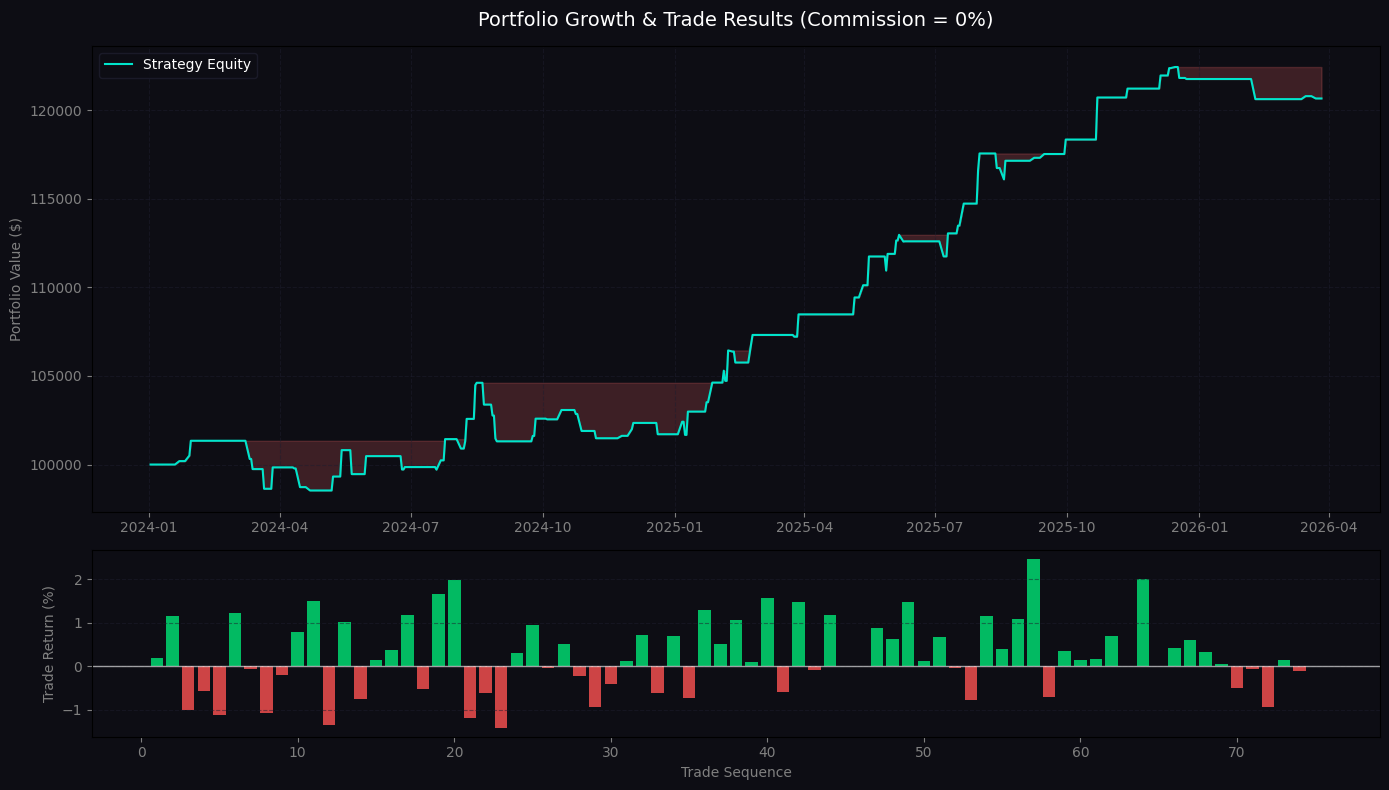

,Entry Date,Exit Date,Direction,Holding Days,Return (%),Profit/Loss ($),Cumulative Equity ($)
0,2024-01-22,2024-01-23,Long,1,0.19,190.00,100190.00
1,2024-01-29,2024-01-31,Long,2,1.15,1152.18,101342.18
2,2024-03-11,2024-03-12,Long,1,-1.01,-1023.56,100318.63
3,2024-03-13,2024-03-14,Long,1,-0.57,-571.82,99746.81
4,2024-03-21,2024-03-22,Long,1,-1.11,-1107.19,98639.62
...,...,...,...,...,...,...,...
70,2025-12-23,2025-12-24,Long,1,-0.05,-60.92,121774.99
71,2026-02-09,2026-02-10,Long,1,-0.93,-1132.51,120642.48
72,2026-03-16,2026-03-17,Long,1,0.14,168.90,120811.38
73,2026-03-20,2026-03-24,Long,2,-0.11,-132.89,120678.49


In [12]:
# เรียกใช้งานฟังก์ชัน
daily_df, trade_df = run_backtest('../data/processed/predictions/output.csv', initial_capital=100000, commission_pct=0)

# หากต้องการดูข้อมูลรายไม้แบบเต็มๆ ใน Jupyter Notebook
display(trade_df) 

# หรือถ้าต้องการบันทึกเก็บไว้ดูเป็นไฟล์ Excel
# trade_df.to_excel('trade_log.xlsx', index=False)